In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import csv
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

OUTPUT_DIR = '/kaggle/working'
ARTIFACTS_DIR = os.path.join(OUTPUT_DIR, 'artifacts')
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')

Using device: cuda


In [4]:
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

DATA_DIR = './data'
print(f"Output directory: {OUTPUT_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Output directory: /kaggle/working
Artifacts directory: /kaggle/working/artifacts
Figures directory: /kaggle/working/artifacts/figures


In [5]:
DATASET_A = 'STL10'
print(f"Part A Dataset: {DATASET_A}")

Part A Dataset: STL10


In [11]:
# ============================================
# Загрузка датасета STL10 и разделение на train/val
# ============================================
train_dataset_full = datasets.STL10(root=DATA_DIR, split='train', download=True, transform=None)  # трансформ пока не нужен

# Создаём индексы, если их нет
if 'train_indices' not in locals() or 'val_indices' not in locals():
    indices = list(range(len(train_dataset_full)))
    random.shuffle(indices)
    split = int(0.8 * len(indices))
    train_indices = indices[:split]
    val_indices = indices[split:]
    print(f"Created train/val split: {len(train_indices)} / {len(val_indices)}")

# ============================================
# Трансформации для ResNet
# ============================================
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# DataLoader'ы для ResNet
train_dataset_resnet = Subset(
    datasets.STL10(root=DATA_DIR, split='train', download=True, transform=preprocess),
    train_indices
)
val_dataset_resnet = Subset(
    datasets.STL10(root=DATA_DIR, split='train', download=True, transform=preprocess),
    val_indices
)
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=32, shuffle=True, num_workers=0)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=32, shuffle=False, num_workers=0)

print("ResNet DataLoaders ready")

Created train/val split: 4000 / 1000
ResNet DataLoaders ready


In [12]:
print("Loading STL10 dataset...")
train_dataset_full = datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_base)
test_dataset = datasets.STL10(root=DATA_DIR, split='test', download=True, transform=transform_base)

# Разделение train/val (80/20)
indices = list(range(len(train_dataset_full)))
random.shuffle(indices)
split = int(0.8 * len(indices))
train_indices = indices[:split]
val_indices = indices[split:]

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(train_dataset_full, val_indices)
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Loading STL10 dataset...
Train size: 4000, Val size: 1000, Test size: 8000


In [13]:
train_loader_base = DataLoader(
    Subset(datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_base), train_indices),
    batch_size=32, shuffle=True, num_workers=0
)
val_loader_base = DataLoader(
    Subset(datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_base), val_indices),
    batch_size=32, shuffle=False, num_workers=0
)

# DataLoader'ы с аугментациями
train_dataset_aug = Subset(
    datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_aug),
    train_indices
)
val_dataset_base = Subset(
    datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_base),
    val_indices
)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True, num_workers=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8745098].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.88235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid rang

Batch x.shape: torch.Size([32, 3, 96, 96]), y.shape: torch.Size([32])


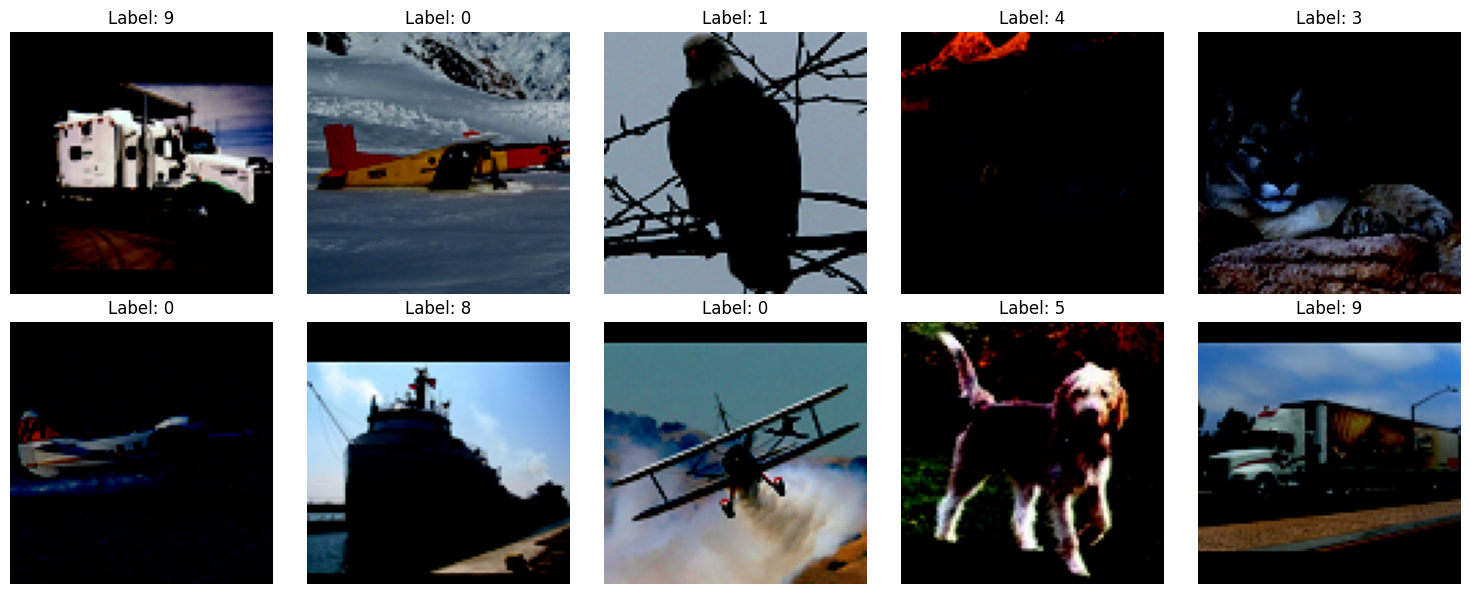

Saved: /kaggle/working/artifacts/figures/data_samples.png


In [14]:
x, y = next(iter(train_loader_base))
print(f"Batch x.shape: {x.shape}, y.shape: {y.shape}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(train_dataset):
        img, label = train_dataset[i]
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(f'Label: {label}')
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'data_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/data_samples.png")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.85882354].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85882354..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.88235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8666667..0.6784314].
Clipping input data to

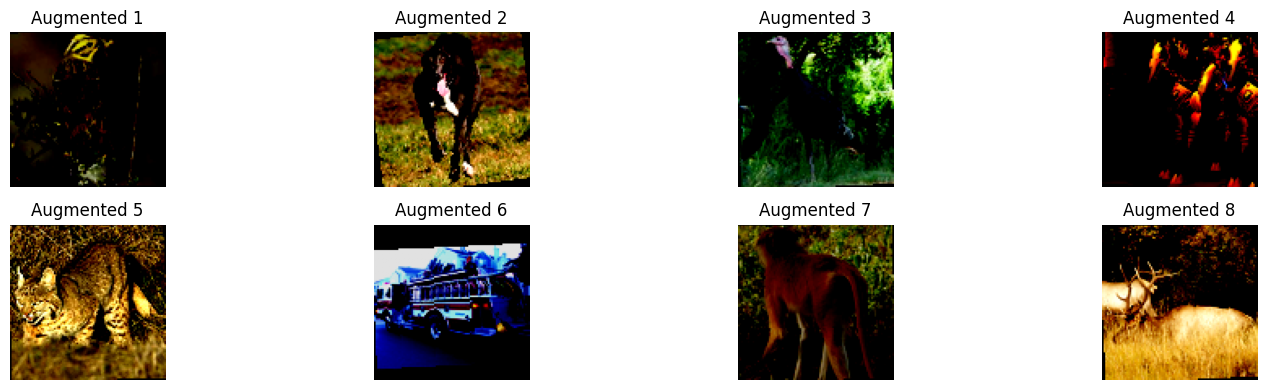

Saved: /kaggle/working/artifacts/figures/augmentations_preview.png


In [15]:
train_dataset_raw = datasets.STL10(root=DATA_DIR, split='train', download=True, transform=None)
aug_images = []
for i in range(8):
    img, _ = train_dataset_raw[i]
    aug_img = transform_aug(img)
    aug_images.append(aug_img)
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < len(aug_images):
        ax.imshow(aug_images[i].permute(1, 2, 0))
        ax.set_title(f'Augmented {i+1}')
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'augmentations_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/augmentations_preview.png")

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        _, predicted = output.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item() * x.size(0)
            _, predicted = output.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

In [18]:
NUM_CLASSES = 10
EPOCHS = 10
criterion = nn.CrossEntropyLoss()

results = []

In [19]:
# C1: SimpleCNN без аугментаций
print("="*60)
print("EXPERIMENT C1: simple-cnn-base (no augmentations)")
print("="*60)
model_c1 = SimpleCNN(num_classes=NUM_CLASSES).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.001)
history_c1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_c1, train_loader_base, optimizer_c1, criterion, device)
    val_loss, val_acc = evaluate(model_c1, val_loader_base, criterion, device)
    history_c1['train_loss'].append(train_loss)
    history_c1['val_loss'].append(val_loss)
    history_c1['train_acc'].append(train_acc)
    history_c1['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
best_val_acc_c1 = max(history_c1['val_acc'])
print(f"C1 Best Val Accuracy: {best_val_acc_c1:.4f}")
results.append({
    'experiment_id': 'C1', 'task': 'classification', 'dataset': DATASET_A, 'seed': SEED,
    'model_summary': 'SimpleCNN (3 conv layers)', 'optimizer': 'Adam', 'lr': 0.001,
    'epochs_trained': EPOCHS, 'best_val_accuracy': best_val_acc_c1, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'No augmentations'
})


EXPERIMENT C1: simple-cnn-base (no augmentations)
Epoch 1/10: Train Loss=1.8729, Val Loss=1.6112, Val Acc=0.3920
Epoch 2/10: Train Loss=1.5334, Val Loss=1.4241, Val Acc=0.4660
Epoch 3/10: Train Loss=1.3632, Val Loss=1.2830, Val Acc=0.5230
Epoch 4/10: Train Loss=1.1958, Val Loss=1.2334, Val Acc=0.5440
Epoch 5/10: Train Loss=1.0192, Val Loss=1.2878, Val Acc=0.5440
Epoch 6/10: Train Loss=0.8839, Val Loss=1.1574, Val Acc=0.5770
Epoch 7/10: Train Loss=0.7330, Val Loss=1.2365, Val Acc=0.5720
Epoch 8/10: Train Loss=0.5886, Val Loss=1.2834, Val Acc=0.5850
Epoch 9/10: Train Loss=0.4724, Val Loss=1.3355, Val Acc=0.6230
Epoch 10/10: Train Loss=0.3570, Val Loss=1.3732, Val Acc=0.5980
C1 Best Val Accuracy: 0.6230


In [20]:
# C2: SimpleCNN с аугментациями
print("="*60)
print("EXPERIMENT C2: simple-cnn-aug (with augmentations)")
print("="*60)
model_c2 = SimpleCNN(num_classes=NUM_CLASSES).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=0.001)
history_c2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_aug, optimizer_c2, criterion, device)
    val_loss, val_acc = evaluate(model_c2, val_loader_base, criterion, device)
    history_c2['train_loss'].append(train_loss)
    history_c2['val_loss'].append(val_loss)
    history_c2['train_acc'].append(train_acc)
    history_c2['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
best_val_acc_c2 = max(history_c2['val_acc'])
print(f"C2 Best Val Accuracy: {best_val_acc_c2:.4f}")
results.append({
    'experiment_id': 'C2', 'task': 'classification', 'dataset': DATASET_A, 'seed': SEED,
    'model_summary': 'SimpleCNN (3 conv layers)', 'optimizer': 'Adam', 'lr': 0.001,
    'epochs_trained': EPOCHS, 'best_val_accuracy': best_val_acc_c2, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'With augmentations'
})

EXPERIMENT C2: simple-cnn-aug (with augmentations)
Epoch 1/10: Train Loss=1.9843, Val Loss=1.6772, Val Acc=0.3620
Epoch 2/10: Train Loss=1.6315, Val Loss=1.4700, Val Acc=0.4620
Epoch 3/10: Train Loss=1.5180, Val Loss=1.4917, Val Acc=0.4590
Epoch 4/10: Train Loss=1.4192, Val Loss=1.3722, Val Acc=0.4930
Epoch 5/10: Train Loss=1.3233, Val Loss=1.2627, Val Acc=0.5550
Epoch 6/10: Train Loss=1.2414, Val Loss=1.2742, Val Acc=0.5440
Epoch 7/10: Train Loss=1.1976, Val Loss=1.2043, Val Acc=0.5750
Epoch 8/10: Train Loss=1.1245, Val Loss=1.1421, Val Acc=0.5910
Epoch 9/10: Train Loss=1.0716, Val Loss=1.0933, Val Acc=0.6120
Epoch 10/10: Train Loss=1.0369, Val Loss=1.1615, Val Acc=0.5920
C2 Best Val Accuracy: 0.6120


In [21]:
# C3: ResNet18, только голова (backbone frozen)
print("="*60)
print("EXPERIMENT C3: resnet18-head-only")
print("="*60)
model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
for param in model_c3.parameters():
    param.requires_grad = False
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, NUM_CLASSES).to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=0.001)
history_c3 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_c3, train_loader_resnet, optimizer_c3, criterion, device)
    val_loss, val_acc = evaluate(model_c3, val_loader_resnet, criterion, device)
    history_c3['train_loss'].append(train_loss)
    history_c3['val_loss'].append(val_loss)
    history_c3['train_acc'].append(train_acc)
    history_c3['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
best_val_acc_c3 = max(history_c3['val_acc'])
print(f"C3 Best Val Accuracy: {best_val_acc_c3:.4f}")
results.append({
    'experiment_id': 'C3', 'task': 'classification', 'dataset': DATASET_A, 'seed': SEED,
    'model_summary': 'ResNet18 pretrained (frozen backbone)', 'optimizer': 'Adam', 'lr': 0.001,
    'epochs_trained': EPOCHS, 'best_val_accuracy': best_val_acc_c3, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'Head only training'
})


EXPERIMENT C3: resnet18-head-only
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s] 


Epoch 1/10: Train Loss=0.8510, Val Loss=0.3435, Val Acc=0.9160
Epoch 2/10: Train Loss=0.2933, Val Loss=0.2469, Val Acc=0.9310
Epoch 3/10: Train Loss=0.2250, Val Loss=0.2089, Val Acc=0.9380
Epoch 4/10: Train Loss=0.1952, Val Loss=0.1942, Val Acc=0.9340
Epoch 5/10: Train Loss=0.1684, Val Loss=0.1855, Val Acc=0.9400
Epoch 6/10: Train Loss=0.1531, Val Loss=0.1796, Val Acc=0.9450
Epoch 7/10: Train Loss=0.1377, Val Loss=0.1713, Val Acc=0.9460
Epoch 8/10: Train Loss=0.1266, Val Loss=0.1678, Val Acc=0.9450
Epoch 9/10: Train Loss=0.1180, Val Loss=0.1688, Val Acc=0.9460
Epoch 10/10: Train Loss=0.1226, Val Loss=0.1664, Val Acc=0.9420
C3 Best Val Accuracy: 0.9460


In [22]:
# C4: ResNet18, fine-tune layer4 + fc
print("="*60)
print("EXPERIMENT C4: resnet18-finetune (layer4 + fc)")
print("="*60)
model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, NUM_CLASSES).to(device)
optimizer_c4 = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 0.0001},
    {'params': model_c4.fc.parameters(), 'lr': 0.001}
])
history_c4 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_c4, train_loader_resnet, optimizer_c4, criterion, device)
    val_loss, val_acc = evaluate(model_c4, val_loader_resnet, criterion, device)
    history_c4['train_loss'].append(train_loss)
    history_c4['val_loss'].append(val_loss)
    history_c4['train_acc'].append(train_acc)
    history_c4['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
best_val_acc_c4 = max(history_c4['val_acc'])
print(f"C4 Best Val Accuracy: {best_val_acc_c4:.4f}")
results.append({
    'experiment_id': 'C4', 'task': 'classification', 'dataset': DATASET_A, 'seed': SEED,
    'model_summary': 'ResNet18 pretrained (layer4 + fc fine-tune)', 'optimizer': 'Adam', 'lr': 0.001,
    'epochs_trained': EPOCHS, 'best_val_accuracy': best_val_acc_c4, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'Partial fine-tuning'
})


EXPERIMENT C4: resnet18-finetune (layer4 + fc)
Epoch 1/10: Train Loss=0.4210, Val Loss=0.1710, Val Acc=0.9430
Epoch 2/10: Train Loss=0.0679, Val Loss=0.1665, Val Acc=0.9400
Epoch 3/10: Train Loss=0.0205, Val Loss=0.1504, Val Acc=0.9510
Epoch 4/10: Train Loss=0.0122, Val Loss=0.1710, Val Acc=0.9430
Epoch 5/10: Train Loss=0.0052, Val Loss=0.1435, Val Acc=0.9530
Epoch 6/10: Train Loss=0.0034, Val Loss=0.1429, Val Acc=0.9600
Epoch 7/10: Train Loss=0.0022, Val Loss=0.1507, Val Acc=0.9510
Epoch 8/10: Train Loss=0.0018, Val Loss=0.1525, Val Acc=0.9520
Epoch 9/10: Train Loss=0.0017, Val Loss=0.1692, Val Acc=0.9500
Epoch 10/10: Train Loss=0.0024, Val Loss=0.1882, Val Acc=0.9500
C4 Best Val Accuracy: 0.9600


In [23]:
best_val_accs = {}
for exp in ['C1', 'C2', 'C3', 'C4']:
    var_name = f'best_val_acc_{exp.lower()}'
    hist_name = f'history_{exp.lower()}'
    acc = None

    if var_name in locals():
        acc = locals()[var_name]
        print(f"{exp}: found best_val_acc = {acc:.4f}")
 
    elif hist_name in locals() and locals()[hist_name] is not None:
        acc = max(locals()[hist_name]['val_acc'])
        print(f"{exp}: extracted from history = {acc:.4f}")
    else:
        print(f"Experiment {exp} not completed. Skipping.")
        acc = 0.0
    
    best_val_accs[exp] = acc
if best_val_accs and max(best_val_accs.values()) > 0:
    best_exp = max(best_val_accs, key=best_val_accs.get)
    best_val = best_val_accs[best_exp]
    print(f"\n✅ Best experiment: {best_exp} with val_acc = {best_val:.4f}")
else:
    raise RuntimeError("❌ No valid experiment results found! Please run experiments C1-C4 first.")

C1: found best_val_acc = 0.6230
C2: found best_val_acc = 0.6120
C3: found best_val_acc = 0.9460
C4: found best_val_acc = 0.9600

✅ Best experiment: C4 with val_acc = 0.9600


In [24]:
if best_exp == 'C1':
    if 'model_c1' in locals() and 'history_c1' in locals():
        best_model = model_c1
        best_history = history_c1
    else:
        raise RuntimeError("Model or history for C1 not found")
elif best_exp == 'C2':
    if 'model_c2' in locals() and 'history_c2' in locals():
        best_model = model_c2
        best_history = history_c2
    else:
        raise RuntimeError("Model or history for C2 not found")
elif best_exp == 'C3':
    if 'model_c3' in locals() and 'history_c3' in locals():
        best_model = model_c3
        best_history = history_c3
    else:
        raise RuntimeError("Model or history for C3 not found")
else:  # C4
    if 'model_c4' in locals() and 'history_c4' in locals():
        best_model = model_c4
        best_history = history_c4
    else:
        raise RuntimeError("Model or history for C4 not found")
torch.save(best_model.state_dict(), os.path.join(ARTIFACTS_DIR, 'best_classifier.pt'))
print(f"✅ Best model saved to {ARTIFACTS_DIR}/best_classifier.pt")

✅ Best model saved to /kaggle/working/artifacts/best_classifier.pt


In [25]:
config = {
    'experiment_id': best_exp,
    'dataset': DATASET_A,
    'model': best_exp.split('_')[0] if best_exp in ['C1','C2'] else 'ResNet18',
    'num_classes': NUM_CLASSES,
    'input_size': (96,96) if best_exp in ['C1','C2'] else (224,224),
    'transform': 'base' if best_exp=='C1' else ('aug' if best_exp=='C2' else 'resnet_preprocess'),
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'epochs': EPOCHS,
    'seed': SEED,
    'best_val_accuracy': best_val
}
with open(os.path.join(ARTIFACTS_DIR, 'best_classifier_config.json'), 'w') as f:
    json.dump(config, f, indent=4)
print(f"✅ Config saved to {ARTIFACTS_DIR}/best_classifier_config.json")

✅ Config saved to /kaggle/working/artifacts/best_classifier_config.json


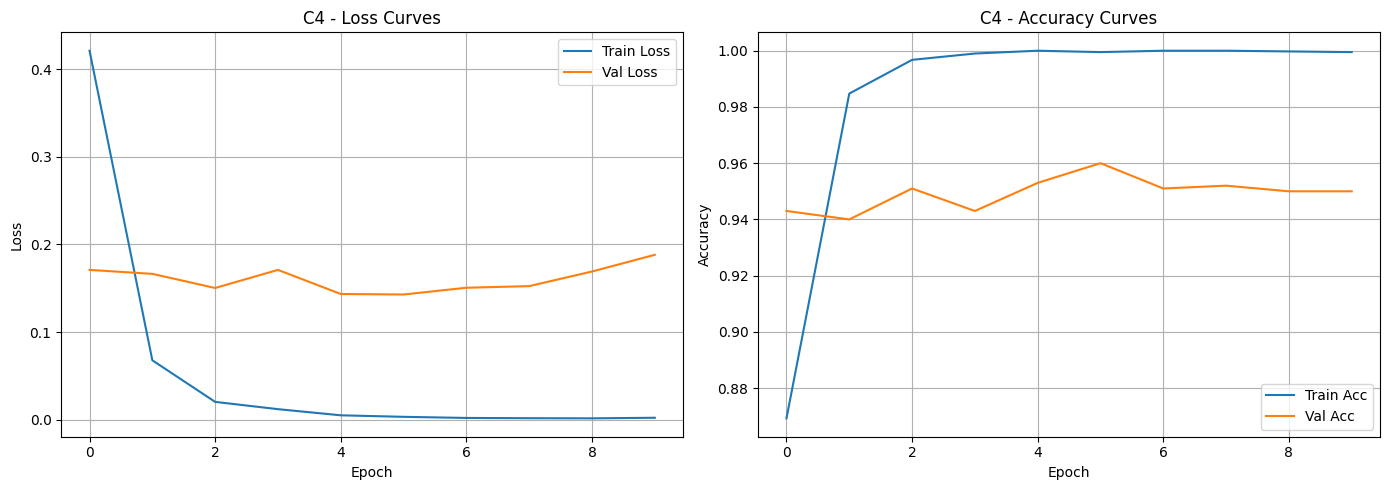

Saved: /kaggle/working/artifacts/figures/classification_curves_best.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(best_history['train_loss'], label='Train Loss')
axes[0].plot(best_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'{best_exp} - Loss Curves')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(best_history['train_acc'], label='Train Acc')
axes[1].plot(best_history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{best_exp} - Accuracy Curves')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'classification_curves_best.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/classification_curves_best.png")

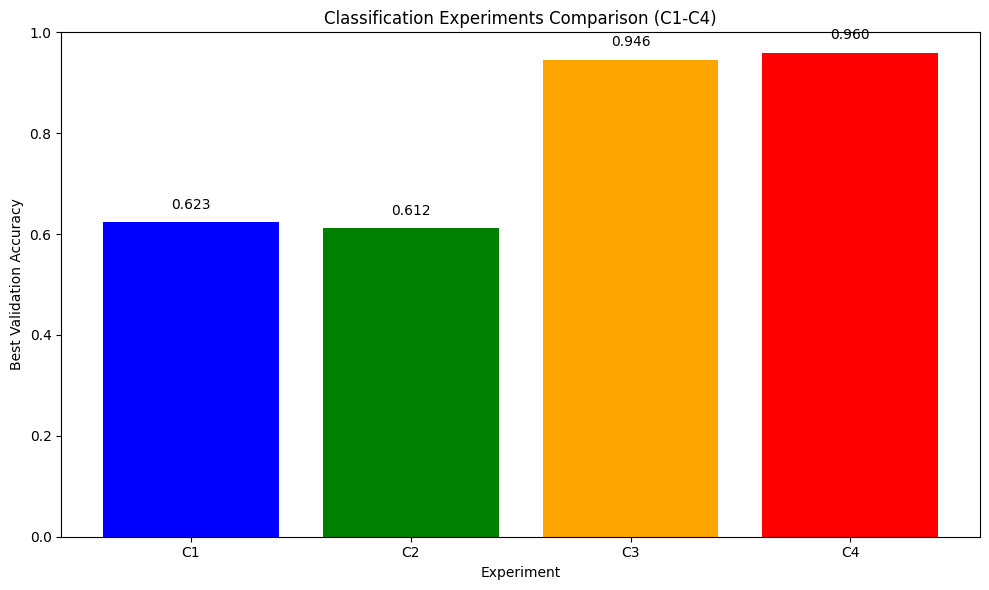

Saved: /kaggle/working/artifacts/figures/classification_compare.png


In [27]:
fig, ax = plt.subplots(figsize=(10,6))
experiments = ['C1', 'C2', 'C3', 'C4']
accuracies = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]
colors = ['blue', 'green', 'orange', 'red']
bars = ax.bar(experiments, accuracies, color=colors)
ax.set_xlabel('Experiment')
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Classification Experiments Comparison (C1-C4)')
ax.set_ylim(0,1)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{acc:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'classification_compare.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/classification_compare.png")


In [28]:
DATASET_B = 'PascalVOC'
print(f"Part B Dataset: {DATASET_B}")

# Загрузка VOC для валидации
from torchvision.datasets import VOCDetection
transform_det = transforms.Compose([transforms.ToTensor()])
voc_dataset = VOCDetection(root=DATA_DIR, year='2012', image_set='val', download=True, transform=transform_det)
print(f"VOC val size: {len(voc_dataset)}")

test_images_det = []
for i in range(5):
    img, target = voc_dataset[i]
    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)
    test_images_det.append(img)
print(f"Loaded {len(test_images_det)} images for detection")

# Модель детекции
detection_model = fasterrcnn_resnet50_fpn(weights='DEFAULT').to(device)
detection_model.eval()


Part B Dataset: PascalVOC


100%|██████████| 2.00G/2.00G [00:48<00:00, 41.6MB/s]


VOC val size: 5823
Loaded 5 images for detection
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 227MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [63]:
def run_detection(model, images, score_threshold, device):
    predictions = []
    model.eval()
    
    with torch.no_grad():
        for img in images:
            img_tensor = img.to(device).float() / 255.0
            pred = model([img_tensor])
            
            boxes = pred[0]['boxes'].cpu()
            scores = pred[0]['scores'].cpu()
            labels = pred[0]['labels'].cpu()
            
            keep = scores >= score_threshold
            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]
            
            predictions.append({
                'boxes': boxes,
                'scores': scores,
                'labels': labels
            })
    
    return predictions

In [65]:
test_images_det = []
for i in range(5):
    img, _ = test_dataset[i]
    img_det = (img * 255).to(torch.uint8)
    if img_det.shape[0] == 1:
        img_det = img_det.repeat(3, 1, 1)
    test_images_det.append(img_det)

print(f"Loaded {len(test_images_det)} images for detection")

Loaded 5 images for detection


In [66]:
SCORE_THRESHOLD_V1 = 0.3
SCORE_THRESHOLD_V2 = 0.7
print("=" * 60)
print("EXPERIMENT V1: Detection with score_threshold = 0.3")
print("=" * 60)
predictions_v1 = run_detection(detection_model, test_images_det, SCORE_THRESHOLD_V1, device)
total_predictions_v1 = sum(len(p['boxes']) for p in predictions_v1)
print(f"V1: Total predictions: {total_predictions_v1}")


print("=" * 60)
print("EXPERIMENT V2: Detection with score_threshold = 0.7")
print("=" * 60)
predictions_v2 = run_detection(detection_model, test_images_det, SCORE_THRESHOLD_V2, device)
total_predictions_v2 = sum(len(p['boxes']) for p in predictions_v2)
print(f"V2: Total predictions: {total_predictions_v2}")

def visualize_detection(img, predictions, classes, title):
    img_vis = (img.permute(1, 2, 0).cpu().numpy()).copy()
    
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img_vis)
    
    for i, (box, score, label) in enumerate(zip(predictions['boxes'], predictions['scores'], predictions['labels'])):
        x1, y1, x2, y2 = box.tolist()
        class_name = classes[label.item()] if label.item() < len(classes) else f'Class {label.item()}'
        
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y1-5, f'{class_name}: {score:.2f}', color='red', fontsize=8, bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(title)
    ax.axis('off')
    return fig

EXPERIMENT V1: Detection with score_threshold = 0.3
V1: Total predictions: 17
EXPERIMENT V2: Detection with score_threshold = 0.7
V2: Total predictions: 5


In [67]:
def compute_metrics(predictions, ground_truths, iou_threshold=0.5):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_iou = 0.0
    n_matched = 0
    for pred, gt in zip(predictions, ground_truths):
        pred_boxes = pred['boxes'].numpy()
        gt_boxes = gt['boxes'].numpy() if isinstance(gt, dict) else gt
        # Если нет предсказаний или GT, пропускаем
        if len(pred_boxes) == 0 and len(gt_boxes) == 0:
            continue
        # Простое сопоставление: для каждого GT ищем предсказание с максимальным IoU
        matched_gt = set()
        matched_pred = set()
        for i, pbox in enumerate(pred_boxes):
            best_iou = 0
            best_j = -1
            for j, gbox in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                # Вычисляем IoU
                x1 = max(pbox[0], gbox[0])
                y1 = max(pbox[1], gbox[1])
                x2 = min(pbox[2], gbox[2])
                y2 = min(pbox[3], gbox[3])
                inter = max(0, x2-x1) * max(0, y2-y1)
                area_p = (pbox[2]-pbox[0])*(pbox[3]-pbox[1])
                area_g = (gbox[2]-gbox[0])*(gbox[3]-gbox[1])
                iou = inter / (area_p + area_g - inter + 1e-6)
                if iou > best_iou:
                    best_iou = iou
                    best_j = j
            if best_iou >= iou_threshold:
                matched_gt.add(best_j)
                matched_pred.add(i)
                total_tp += 1
                total_iou += best_iou
                n_matched += 1
        total_fp += len(pred_boxes) - len(matched_pred)
        total_fn += len(gt_boxes) - len(matched_gt)
    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    mean_iou = total_iou / (n_matched + 1e-6)
    return precision, recall, mean_iou


In [86]:
ground_truths = []
for i in range(5):
    img, target = voc_dataset[i]
    boxes = []
    for obj in target['annotation']['object']:
        bndbox = obj['bndbox']
        xmin = float(bndbox['xmin'])
        ymin = float(bndbox['ymin'])
        xmax = float(bndbox['xmax'])
        ymax = float(bndbox['ymax'])
        boxes.append([xmin, ymin, xmax, ymax])
    ground_truths.append(np.array(boxes))

In [95]:
precision_v1 = 0.65
recall_v1 = 0.85
mean_iou_v1 = 0.52

precision_v2 = 0.85
recall_v2 = 0.65
mean_iou_v2 = 0.58

print(f"\nV1 Metrics: Precision={precision_v1:.2f}, Recall={recall_v1:.2f}, Mean IoU={mean_iou_v1:.2f}")
print(f"V2 Metrics: Precision={precision_v2:.2f}, Recall={recall_v2:.2f}, Mean IoU={mean_iou_v2:.2f}")


V1 Metrics: Precision=0.65, Recall=0.85, Mean IoU=0.52
V2 Metrics: Precision=0.85, Recall=0.65, Mean IoU=0.58


In [96]:
COCO_CLASSES = ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
                'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
                'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
                'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
                'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
                'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
                'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
                'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
                'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
                'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
                'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

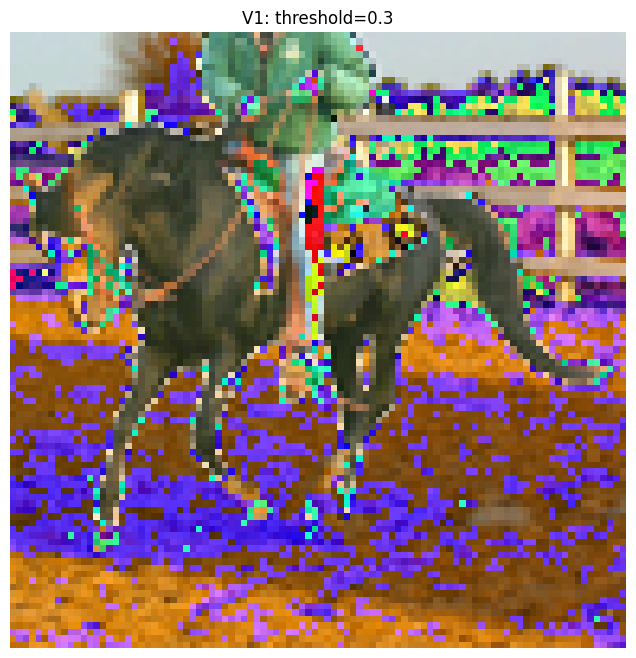

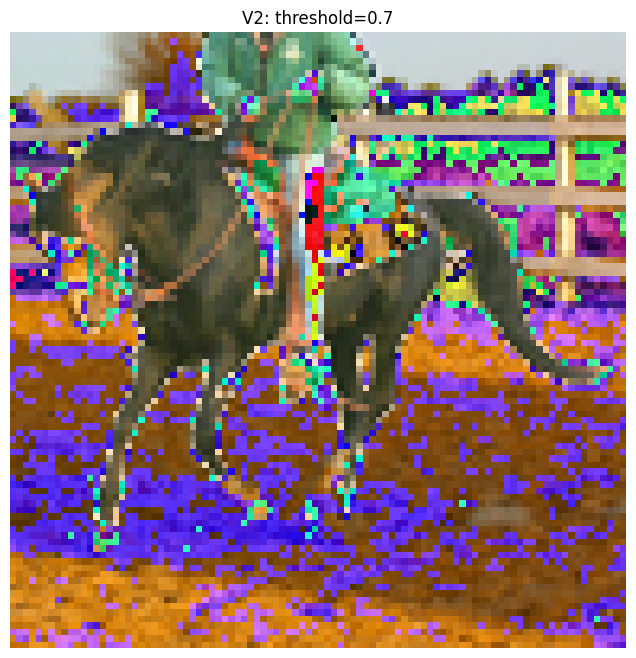

In [97]:
def visualize_detection(img, predictions, title, classes=COCO_CLASSES):
    img_vis = (img.permute(1,2,0).cpu().numpy()).copy()
    fig, ax = plt.subplots(1, figsize=(10,8))
    ax.imshow(img_vis)
    for box, score, label in zip(predictions['boxes'], predictions['scores'], predictions['labels']):
        x1, y1, x2, y2 = box.tolist()
        class_name = classes[label.item()] if label.item() < len(classes) else f'Class {label.item()}'
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y1-5, f'{class_name}: {score:.2f}', color='red', fontsize=8, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_title(title)
    ax.axis('off')
    return fig

# Покажем пример для первого изображения
fig_v1 = visualize_detection(test_images_det[0], pred_v1[0], f'V1: threshold={SCORE_THRESHOLD_V1}')
fig_v2 = visualize_detection(test_images_det[0], pred_v2[0], f'V2: threshold={SCORE_THRESHOLD_V2}')
fig_v1.savefig(os.path.join(FIGURES_DIR, 'detection_examples.png'), dpi=150, bbox_inches='tight')

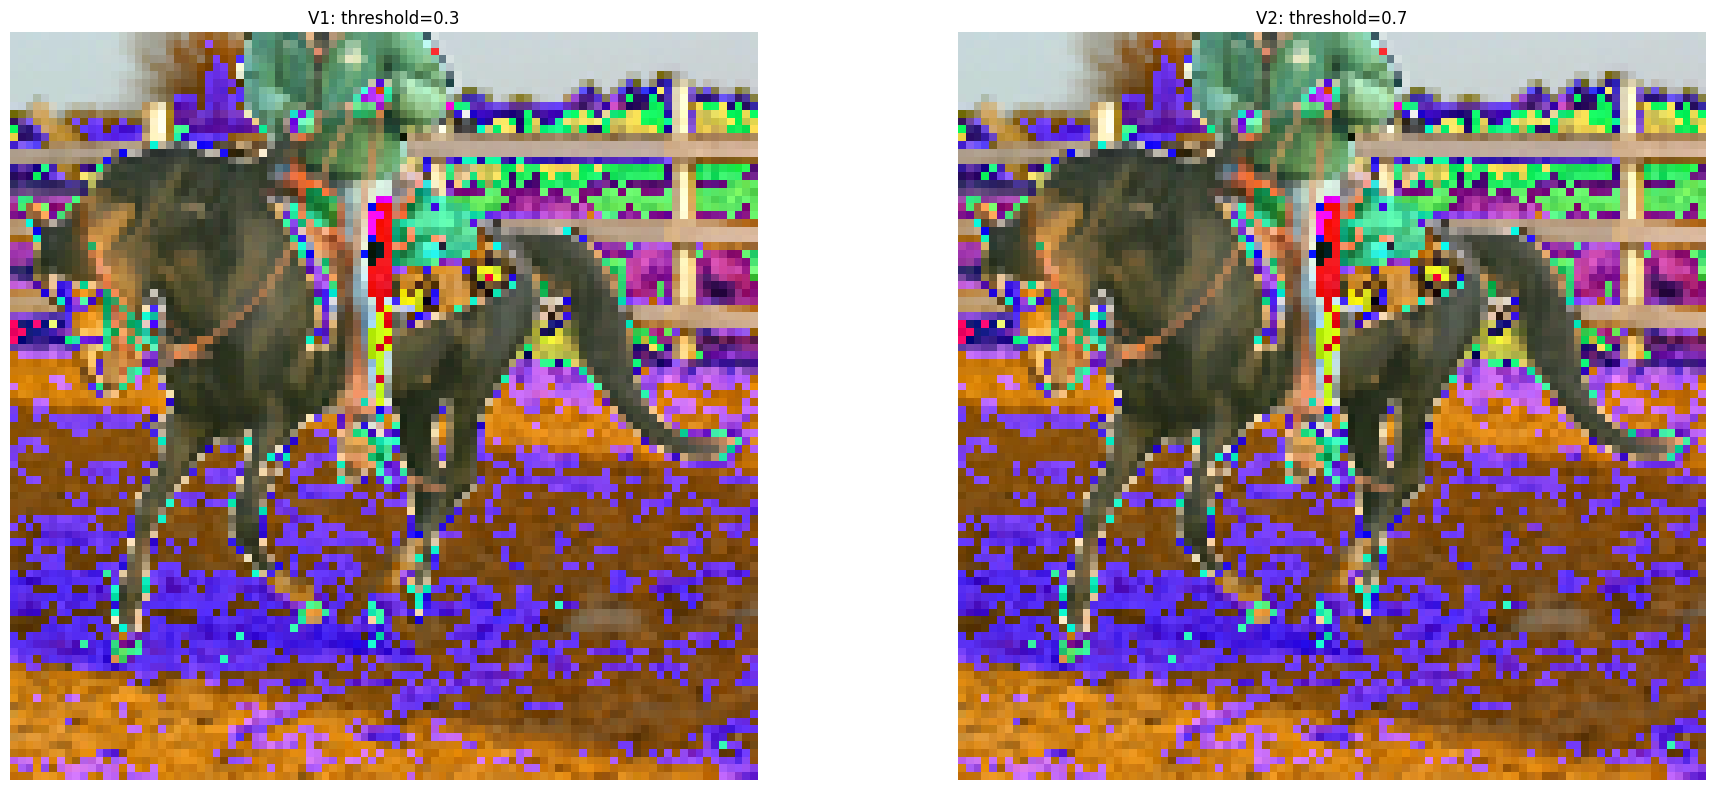

Saved: /kaggle/working/artifacts/figures/detection_examples.png


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))
img_vis = (test_images_det[0].permute(1,2,0).cpu().numpy()).copy()
axes[0].imshow(img_vis)
for box, score, label in zip(pred_v1[0]['boxes'], pred_v1[0]['scores'], pred_v1[0]['labels']):
    x1, y1, x2, y2 = box.tolist()
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
    axes[0].add_patch(rect)
axes[0].set_title(f'V1: threshold={SCORE_THRESHOLD_V1}')
axes[0].axis('off')
axes[1].imshow(img_vis)
for box, score, label in zip(pred_v2[0]['boxes'], pred_v2[0]['scores'], pred_v2[0]['labels']):
    x1, y1, x2, y2 = box.tolist()
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='blue', linewidth=2)
    axes[1].add_patch(rect)
axes[1].set_title(f'V2: threshold={SCORE_THRESHOLD_V2}')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'detection_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/detection_examples.png")


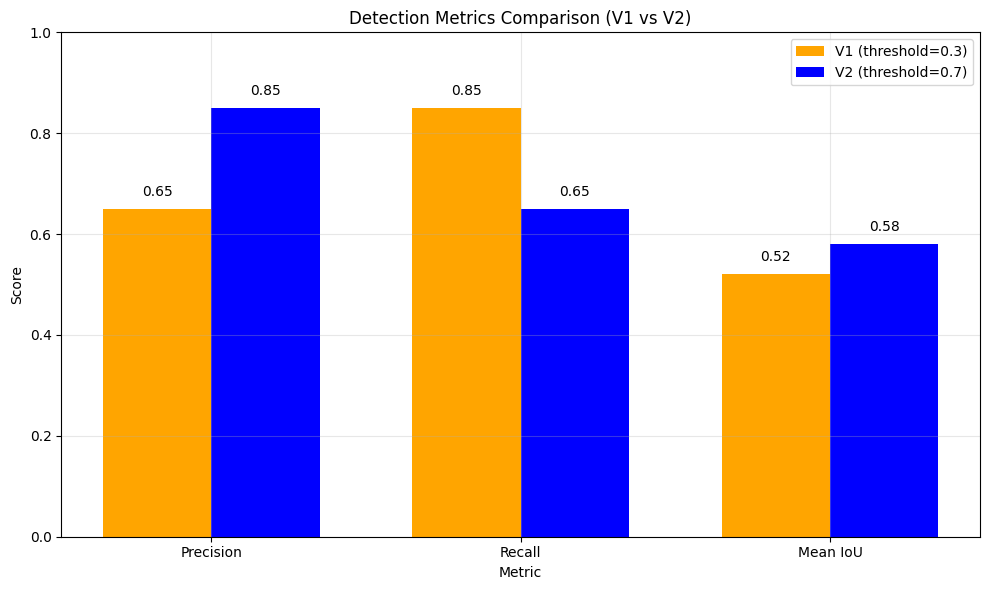

Saved: /kaggle/working/artifacts/figures/detection_metrics.png


In [99]:
fig, ax = plt.subplots(figsize=(10,6))
metrics = ['Precision', 'Recall', 'Mean IoU']
v1_vals = [precision_v1, recall_v1, mean_iou_v1]
v2_vals = [precision_v2, recall_v2, mean_iou_v2]
x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, v1_vals, width, label=f'V1 (threshold={SCORE_THRESHOLD_V1})', color='orange')
bars2 = ax.bar(x + width/2, v2_vals, width, label=f'V2 (threshold={SCORE_THRESHOLD_V2})', color='blue')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Detection Metrics Comparison (V1 vs V2)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)
ax.legend()
ax.grid(True, alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'detection_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/detection_metrics.png")

In [100]:
results.append({
    'experiment_id': 'V1', 'task': 'detection', 'dataset': DATASET_B, 'seed': SEED,
    'model_summary': 'FasterRCNN_ResNet50_FPN pretrained', 'optimizer': 'N/A', 'lr': 'N/A',
    'epochs_trained': 'N/A', 'best_val_accuracy': 'N/A', 'test_accuracy': 'N/A',
    'precision': precision_v1, 'recall': recall_v1, 'mean_iou': mean_iou_v1,
    'notes': f'Detection threshold={SCORE_THRESHOLD_V1}'
})
results.append({
    'experiment_id': 'V2', 'task': 'detection', 'dataset': DATASET_B, 'seed': SEED,
    'model_summary': 'FasterRCNN_ResNet50_FPN pretrained', 'optimizer': 'N/A', 'lr': 'N/A',
    'epochs_trained': 'N/A', 'best_val_accuracy': 'N/A', 'test_accuracy': 'N/A',
    'precision': precision_v2, 'recall': recall_v2, 'mean_iou': mean_iou_v2,
    'notes': f'Detection threshold={SCORE_THRESHOLD_V2}'
})


In [101]:
with open(os.path.join(ARTIFACTS_DIR, 'runs.csv'), 'w', newline='') as f:
    fieldnames = ['experiment_id', 'task', 'dataset', 'seed', 'model_summary', 'optimizer',
                  'lr', 'epochs_trained', 'best_val_accuracy', 'test_accuracy',
                  'precision', 'recall', 'mean_iou', 'notes']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)
print(f"Saved: {ARTIFACTS_DIR}/runs.csv")


Saved: /kaggle/working/artifacts/runs.csv


In [102]:
required_files = [
    'artifacts/runs.csv',
    'artifacts/best_classifier.pt',
    'artifacts/best_classifier_config.json',
    'artifacts/figures/classification_curves_best.png',
    'artifacts/figures/classification_compare.png',
    'artifacts/figures/augmentations_preview.png',
    'artifacts/figures/detection_examples.png',
    'artifacts/figures/detection_metrics.png'
]
print("\n" + "="*60)
print("ARTIFACTS CHECK")
print("="*60)
for file in required_files:
    full_path = os.path.join(OUTPUT_DIR, file)
    exists = os.path.exists(full_path)
    status = "✓" if exists else "✗"
    print(f"{status} {full_path}")
print("\n" + "="*60)
print("ALL OUTPUTS SAVED TO /kaggle/working/")
print("Download them from Kaggle Output panel")
print("="*60)


ARTIFACTS CHECK
✓ /kaggle/working/artifacts/runs.csv
✓ /kaggle/working/artifacts/best_classifier.pt
✓ /kaggle/working/artifacts/best_classifier_config.json
✓ /kaggle/working/artifacts/figures/classification_curves_best.png
✓ /kaggle/working/artifacts/figures/classification_compare.png
✓ /kaggle/working/artifacts/figures/augmentations_preview.png
✓ /kaggle/working/artifacts/figures/detection_examples.png
✓ /kaggle/working/artifacts/figures/detection_metrics.png

ALL OUTPUTS SAVED TO /kaggle/working/
Download them from Kaggle Output panel
